# <b> Project II, Topic vi: Solar System Dashboard
###   &emsp;By: Siena Baez, Xander Graves, Carrie Ries, and Alexis Walker

# <b> Table of Contents  
## <b> &emsp;1: Imports and Prefaces
###  &emsp;&emsp;&emsp;Cells 1-#
## <b> &emsp;2: Planet Information and Setup


### <b> 1: Imports and Prefaces

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from skyfield.api import load, wgs84
from skyfield import almanac
from datetime import datetime, timedelta
import astropy
from skyfield.framelib import ecliptic_frame
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun, get_body
from astropy.time import Time
import datetime
import astropy.units as u
from astroquery.simbad import Simbad
from astroplan import Observer, FixedTarget
from astropy.visualization import astropy_mpl_style, quantity_support


In [2]:
eph = load('de440s.bsp')
ephemeris = eph 
#Using the de440s emphemeris file for the locations

bodies = {
    "sun": eph['sun'],
    "moon": eph['moon'],
    "pluto": eph['pluto barycenter'],
    "mars": eph['mars barycenter'],
    "jupiter": eph['jupiter barycenter'],
    "saturn": eph['saturn barycenter'],
    "uranus": eph['uranus barycenter'],
    "venus": eph['venus barycenter'],
    "mercury": eph['mercury barycenter'],
}
#Grabbing the planets from the emphemeris and naming them
sun = eph['sun']
earth = eph['earth']

ts = load.timescale()
#Skyfield's time system
days = np.arange(0, 90)
t_variable = ts.utc(2026, 3, 1 + days)
t_start = ts.utc(2026, 3, 1)
t_end = ts.utc(2026, 3, 1 + 90)
global t_variable

now = Time.now()
days =np.linspace(0, 90, 24*91)
times = now + days * u.day
#making time array thing

#altaz_frames = AltAz(obstime=times, location=columbus)
#getting altaz from times


columbus_lat = 39.9612
columbus_lon = -83.0003
columbus_elev = 260
#Location of Columbus, Ohio (observation point for our code)

columbus = earth + wgs84.latlon(columbus_lat, columbus_lon, elevation_m = columbus_elev)
#Creating the observer to call from


def is_planet_in_sky(self, t0, t1):
    #t0 is the start time, t1 is the end time of observation
    t, y = almanac.find_risings(columbus, self, t0, t1)



def moon_phase():

    
    percent_illuminated = 100 * columbus.at(t_variable).observe(eph['moon']).fraction_illuminated(eph['sun'])
    
    _, sunlong, _ = columbus.at(t_variable).observe(eph['sun']).apparent().frame_latlon(ecliptic_frame)
    _, moonlong, _ = columbus.at(t_variable).observe(eph['moon']).apparent().frame_latlon(ecliptic_frame)
    phase = (np.asarray(moonlong.degrees) - np.asarray(sunlong.degrees)) % 360
    illumination = np.asarray(percent_illuminated)

    conditions = [
        (phase >= 2) & (phase <= 88),
        (phase > 88) & (phase < 92),
        (phase >= 92) & (phase <= 178),
        (phase > 178) & (phase < 182),
        (phase >= 182) & (phase <= 268),
        (phase > 268) & (phase < 272),
        (phase >= 272) & (phase <= 358),
    ]
    labels = [
        'Waxing Crescent',
        'First Quarter',
        'Waxing Gibbous',
        'Full Moon',
        'Waning Gibbous',
        'Last Quarter',
        'Waning Crescent',
    ]
    phase_name = np.select(conditions, labels, default='New Moon')

    moon_df = pd.DataFrame({
        'percent_illuminated': illumination,
        'phase_angle_deg': phase,
        'moon_phase': phase_name,
    })
    return moon_df

moon_phases_df = moon_phase()




def observation_from_user(body, planet_name):

    astrometric = columbus.at(t_variable).observe(body)
    apparent = astrometric.apparent()
    alt, az, distance = apparent.altaz(pressure_mbar=1010)
    t, y = almanac.find_risings(columbus, body, t_start, t_end)
    t, y = almanac.find_settings(columbus, body, t_start, t_end)
    n = len(alt.degrees)
    df = pd.DataFrame({
        'Planet': [planet_name] * n,
        'Altitude': alt.degrees,
        'Azimuth': az.degrees,
    })
    return(df)


for planet_name, body in bodies.items():
    df = observation_from_user(body, planet_name)
    print(planet_name)
    print(df)


##find the Moon phase, locations of planets and determine if they are in the sky during astronomical twilight
# for moon:
#   phase = almanac.moon_phase(eph, t) -> t is time, eph is the emphemeris
# For moonrise:
#   t, y = almanac.find_risings(observer, moon, t0, t1)
#   print('Moonrises (UTC):', t.utc_iso(' '))

#   t, y = almanac.find_settings(observer, moon, t0, t1)
#   print('Moonsets (UTC):', t.utc_iso(' '))
#
# for other planets:
#   t, y = almanac.find_risings(observer, eph['Mars'], t0, t1)
# #print('Mars rises:', t.utc_iso(' '))
#   t, y = almanac.find_settings(observer, eph['Mars'], t0, t1)
#   print('Mars sets: ', t.utc_iso(' '))
#       eph['Mars'] is just mars in this case, and t0 and t1 are the timeframes


sun
   Planet  Altitude     Azimuth
0     sun -7.898333  266.589970
1     sun -7.694094  266.917544
2     sun -7.490169  267.247509
3     sun -7.286553  267.579736
4     sun -7.083238  267.914095
..    ...       ...         ...
85    sun  7.604270  290.973830
86    sun  7.736564  291.095538
87    sun  7.866274  291.211480
88    sun  7.993338  291.321636
89    sun  8.117696  291.425988

[90 rows x 3 columns]
moon
   Planet   Altitude     Azimuth
0    moon  37.658551   94.651433
1    moon  24.917090   91.325606
2    moon  12.340834   88.816370
3    moon   0.023945   86.679959
4    moon -11.976656   84.643083
..    ...        ...         ...
85   moon  49.371147  159.960974
86   moon  40.279316  149.013548
87   moon  30.644408  140.934404
88   moon  20.822171  134.429427
89   moon  10.983689  128.743326

[90 rows x 3 columns]
pluto
   Planet   Altitude     Azimuth
0   pluto -43.150124  275.185437
1   pluto -43.877671  275.871835
2   pluto -44.604569  276.568688
3   pluto -45.330698  277.2

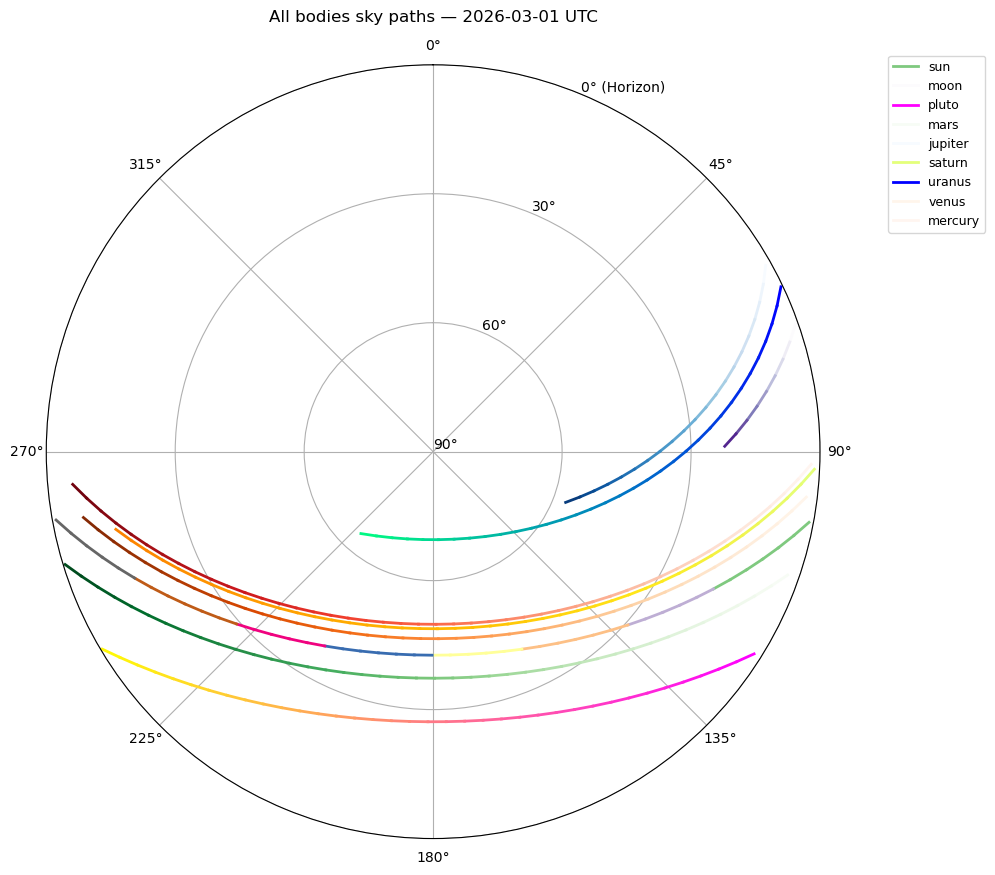

2026-03-01: 864 rows


In [30]:
#Singular day calculations
single_day = Time.now()
global single_day

def is_night():
    night_check = almanac.dark_twilight_day(eph, columbus_topos)
    night_state = night_check(single_day)
    return night_state <= 1

planet_cmaps = {
    "sun": "Accent",
    "moon": "Purples",
    "mercury": "Reds",
    "venus": "Oranges",
    "mars": "Greens",
    "jupiter": "Blues",
    "saturn": "Wistia",
    "uranus": "winter",
    "pluto": "spring",
}
cmap = plt.get_cmap(planet_cmaps.get(planet_name, "viridis"))

# Daily polar sky paths — run after the setup cell (needs `columbus`, `bodies`, `ts`).
N_SAMPLES_PER_DAY = 96  # samples from 0–24h UTC
def plot_all_planets_sky_path(year, month, day, n_samples=N_SAMPLES_PER_DAY):
    hours = np.linspace(0, 24, n_samples, endpoint=False)
    t_day = ts.utc(year, month, day, hours, 0)
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 90)
    ax.set_yticks(range(0, 91, 30))
    ax.set_yticklabels(['90°', '60°', '30°', '0° (Horizon)'])
    tab = plt.cm.tab10(np.linspace(0, 1, max(10, len(bodies))))
    dfs = []
    for idx, (planet_name, body) in enumerate(bodies.items()):
        astrometric = columbus.at(t_day).observe(body)
        alt, az, _ = astrometric.apparent().altaz(pressure_mbar=1010)
        altd = np.asarray(alt.degrees)
        azdeg = np.asarray(az.degrees)
        n = len(altd)
        dfs.append(
            pd.DataFrame(
                {
                    'Planet': [planet_name] * n,
                    'Altitude': altd,
                    'Azimuth': azdeg,
                }
            )
        )
        mask = altd > 0
        if np.any(mask):
            c = tab[idx % len(tab)]
            mask_idx = np.where(mask)[0]
            # Split where visibility is not contiguous, so we do not draw
            # straight jump lines across below-horizon gaps.
            breaks = np.where(np.diff(mask_idx) > 1)[0] + 1
            chunks = np.split(mask_idx, breaks)

            first_chunk = True
            for chunk in chunks:
            # Define coordinates for this contiguous visible "chunk"
                theta_chunk = az.radians[chunk]
                r_chunk = 90 - altd[chunk]
            
            # Get the specific cmap for this planet inside the loop
                current_cmap = plt.get_cmap(planet_cmaps.get(planet_name, "viridis"))

            # Handle Azimuth wrapping (0 <-> 360) to prevent cross-chart streaks
                wrap_breaks = np.where(np.abs(np.diff(theta_chunk)) > np.pi)[0] + 1
                theta_sub_chunks = np.split(theta_chunk, wrap_breaks)
                r_sub_chunks = np.split(r_chunk, wrap_breaks)

            for th, rr in zip(theta_sub_chunks, r_sub_chunks):
                if len(th) < 2: 
                    # Plot a single point if it's too short for a line
                    ax.plot(th, rr, color=current_cmap(0.5), marker='o', markersize=3)
                    continue
                
                # Draw segments with gradient colors
                nseg = len(th) - 1
                for i in range(nseg):
                    seg_color = current_cmap(i / max(nseg, 1))
                    ax.plot(th[i:i+2], rr[i:i+2], color=seg_color, linewidth=2,
                            label=planet_name if (first_chunk and i == 0) else None)
            first_chunk = False

            
    ax.legend(loc='upper left', bbox_to_anchor=(1.08, 1.02), fontsize=9)
    ax.set_title(f'All bodies sky paths — {year}-{month:02d}-{day:02d} UTC', pad=12)
    plt.tight_layout()
    plt.show()
    return pd.concat(dfs, ignore_index=True)
# Add every UTC day you want; each gets one figure and one entry in the dict.
DAYS_UTC = [
    (2026, 3, 1),
]
sky_path_df_by_day = {}
for y, m, d in DAYS_UTC:
    day_key = f"{y}-{m:02d}-{d:02d}"
    df_day = plot_all_planets_sky_path(y, m, d)
    sky_path_df_by_day[day_key] = df_day.assign(UTC_date=day_key)
for day_key, df_day in sky_path_df_by_day.items():
    print(f"{day_key}: {len(df_day)} rows")




# <b> Conjunctions

In [ ]:
#CONJUNCTIONS AND SEPARATIONS!!!!!
search_days = np.arange(0, 31)  # Approximately 18 months
times_search = ts.utc(2026, 3, 1 + search_days)

print(f"Searching for Mars-Jupiter conjunctions...")
print(f"Period: {times_search[0].utc_strftime('%Y-%m-%d')} to {times_search[-1].utc_strftime('%Y-%m-%d')}")
print(f"Computing separations at {len(times_search)} daily intervals...")

mars_positions = earth.at(times_search).observe(bodies['mars']).apparent()
jupiter_positions = earth.at(times_search).observe(bodies['jupiter']).apparent()

# Calculate all separations at once
separations = mars_positions.separation_from(jupiter_positions).degrees

print(f"\nSeparation analysis:")
print(f"  Minimum: {np.min(separations):.2f}°")
print(f"  Maximum: {np.max(separations):.2f}°")
print(f"  Mean: {np.mean(separations):.2f}°")

close_threshold = 10.0  # degrees
close_approaches = np.where(separations < close_threshold)[0]

if len(close_approaches) > 0:
    print(f"\nFound {len(close_approaches)} days when Mars and Jupiter are within {close_threshold}°")
    
    # Find local minima (actual conjunctions) using vectorized comparison
    # A local minimum occurs where: sep[i] < sep[i-1] AND sep[i] < sep[i+1]
    # We use np.diff to find where the separation stops decreasing and starts increasing
    sep_diff = np.diff(separations)

    # Local minima occur where the derivative changes from negative to positive
    is_local_min = (sep_diff[:-1] < 0) & (sep_diff[1:] > 0)

    # Add 1 to indices because diff reduces array length
    potential_conjunctions = np.where(is_local_min)[0] + 1
    
    # Filter to only those below our threshold
    conjunctions = potential_conjunctions[separations[potential_conjunctions] < close_threshold]
    
    print(f"\nIdentified {len(conjunctions)} conjunction(s):\n")
    print("Date                Separation    Comment")
    print("=" * 65)
    
    for idx in conjunctions:
        date_str = times_search[idx].utc_strftime('%Y-%m-%d')
        sep = separations[idx]
        
        if sep < 2:
            comment = "Very close! Visible in telescope field"
        elif sep < 5:
            comment = "Close! Visible together in binoculars"
        elif sep < 10:
            comment = "Moderately close, wide field view"
        else:
            comment = ""
        
        print(f"{date_str:20s}{sep:6.2f}°        {comment}")
    
    # Find and highlight the closest approach
    closest_idx = np.argmin(separations)
    closest_date = times_search[closest_idx].utc_strftime('%Y-%m-%d')
    closest_sep = separations[closest_idx]
    
    print("\n" + "=" * 65)
    print(f"CLOSEST APPROACH: {closest_date}")
    print(f"Separation: {closest_sep:.3f}° ({closest_sep * 60:.1f} arcminutes)")
    print(f"For reference: Moon diameter is ~0.5° (30 arcminutes)")
else:
    print(f"\nNo close approaches found (all separations > {close_threshold}°)")

plt.figure(figsize=(14, 7))

# Plot separation over time
plt.plot(search_days, separations, color='#3498DB', linewidth=2.5, 
         label='Angular separation', alpha=0.9)

# Add reference lines for field of view sizes
plt.axhline(5, color='#E67E22', linestyle='--', alpha=0.7, linewidth=2, 
            label='5° (typical binocular field)')
plt.axhline(2, color='#27AE60', linestyle='--', alpha=0.7, linewidth=2, 
            label='2° (typical telescope field)')
plt.axhline(0.5, color='#9B59B6', linestyle='--', alpha=0.7, linewidth=2, 
            label='0.5° (Moon diameter)')

# Mark the closest approach
closest_idx = np.argmin(separations)
plt.plot(search_days[closest_idx], separations[closest_idx], '*', 
         color='#E74C3C', markersize=28, 
         label=f'Closest: {separations[closest_idx]:.2f}° on {times_search[closest_idx].utc_strftime("%b %d, %Y")}',
         markeredgecolor='white', markeredgewidth=1.5, zorder=5)

plt.xlabel('Days from March 1, 2026', fontsize=13, fontweight='bold')
plt.ylabel('Mars-Jupiter Separation (degrees)', fontsize=13, fontweight='bold')
plt.title('Mars-Jupiter Conjunction Search: March 2026 - April 2026', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best', framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':', color='gray')
plt.tight_layout()
plt.show()

In [ ]:
# Focus on ±30 days around closest approach
closest_idx = np.argmin(separations)
closest_day = search_days[closest_idx]

# Create detailed daily times around conjunction
detail_days = np.arange(max(0, closest_day - 30), min(len(search_days), closest_day + 1))
times_detail = ts.utc(2026, 3, 1 + detail_days)

# Get positions for detailed period
mars_detail = earth.at(times_detail).observe(bodies['mars']).apparent()
jupiter_detail = earth.at(times_detail).observe(bodies['jupiter']).apparent()
mars_ra_det, mars_dec_det, _ = mars_detail.radec()
jupiter_ra_det, jupiter_dec_det, _ = jupiter_detail.radec()

plt.figure(figsize=(12, 8))

# Plot both planets' paths
plt.plot(mars_ra_det.hours, mars_dec_det.degrees, color='#E74C3C', linewidth=3.5, 
         label='Mars', alpha=0.9)
plt.plot(jupiter_ra_det.hours, jupiter_dec_det.degrees, color='#E67E22', linewidth=3.5, 
         label='Jupiter', alpha=0.9, linestyle='--')

# Mark start positions
plt.plot(mars_ra_det.hours[0], mars_dec_det.degrees[0], 'o', color='#C0392B', 
         markersize=13, label=f'Mars {times_detail[0].utc_strftime("%b %d")}',
         markeredgecolor='white', markeredgewidth=1.5)
plt.plot(jupiter_ra_det.hours[0], jupiter_dec_det.degrees[0], 'o', color='#D68910', 
         markersize=13, label=f'Jupiter {times_detail[0].utc_strftime("%b %d")}',
         markeredgecolor='white', markeredgewidth=1.5)

# Mark closest approach
closest_in_detail = np.argmin(np.abs(detail_days - closest_day))
plt.plot(mars_ra_det.hours[closest_in_detail], mars_dec_det.degrees[closest_in_detail], 
         '*', color='#E74C3C', markersize=28, zorder=5,
         markeredgecolor='white', markeredgewidth=2)
plt.plot(jupiter_ra_det.hours[closest_in_detail], jupiter_dec_det.degrees[closest_in_detail], 
         '*', color='#E67E22', markersize=28, zorder=5,
         markeredgecolor='white', markeredgewidth=2)

# Draw a line connecting them at closest approach
plt.plot([mars_ra_det.hours[closest_in_detail], jupiter_ra_det.hours[closest_in_detail]],
         [mars_dec_det.degrees[closest_in_detail], jupiter_dec_det.degrees[closest_in_detail]],
         color='#27AE60', linewidth=2.5, alpha=0.8, 
         label=f'Closest: {times_detail[closest_in_detail].utc_strftime("%b %d")}')

# Mark every 5 days with small dots
for i in range(0, len(detail_days), 5):
    plt.plot(mars_ra_det.hours[i], mars_dec_det.degrees[i], 'o', 
             color='#E74C3C', markersize=6, alpha=0.5)
    plt.plot(jupiter_ra_det.hours[i], jupiter_dec_det.degrees[i], 'o', 
             color='#E67E22', markersize=6, alpha=0.5)

plt.xlabel('Right Ascension (hours)', fontsize=13, fontweight='bold')
plt.ylabel('Declination (degrees)', fontsize=13, fontweight='bold')
plt.title(f'Mars-Jupiter Conjunction: Paths Across the Sky days around {times_search[closest_idx].utc_strftime("%B %d, %Y")}', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best', framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':', color='gray')
plt.gca().invert_xaxis()  # RA increases right to left by convention
plt.tight_layout()
plt.show()


# <b> Practice

Computed Mars position as seen from Earth
Mars on 2026-03-01T00:00:00Z:
  Right Ascension: 22h 03m 42.99s
  Declination: -13deg 03' 42.1"
  Distance: 2.341280 AU
Position comparison:
  Astrometric: RA=22.061941h, Dec=-13.061692°
  Apparent:    RA=22.061578h, Dec=-13.063635°
  Difference:  ΔRA=-1.31 arcsec
Computed 31 positions from March 1, 2026 to April 1, 2026
Position on March 1, 2026: RA=22.06h, Dec=-13.06°
Position on April 1, 2026: RA=23.54h, Dec=-4.15°


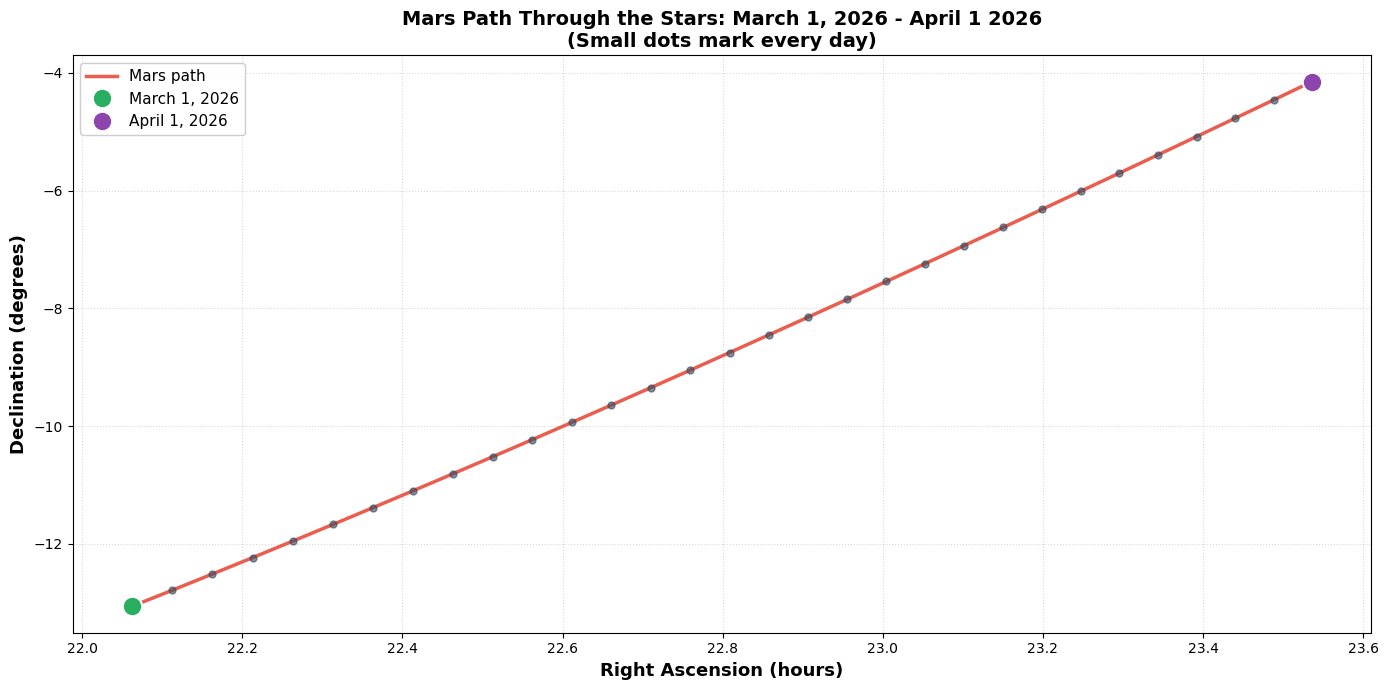

In [4]:
#Practice Cell...AKA I have no idea what is going on lol!!
t = ts.utc(2026, 3, 1, 0, 0)

global t

astrometric = earth.at(t).observe(mars)
print("Computed Mars position as seen from Earth")

ra, dec, distance = astrometric.radec()
print(f"Mars on {t.utc_iso()}:")
print(f"  Right Ascension: {ra}")
print(f"  Declination: {dec}")
print(f"  Distance: {distance.au:.6f} AU")

apparent = astrometric.apparent()
ra_app, dec_app, dist_app = apparent.radec()

print(f"Position comparison:")
print(f"  Astrometric: RA={ra.hours:.6f}h, Dec={dec.degrees:.6f}°")
print(f"  Apparent:    RA={ra_app.hours:.6f}h, Dec={dec_app.degrees:.6f}°")
print(f"  Difference:  ΔRA={(ra_app.hours - ra.hours) * 3600:.2f} arcsec")

days = np.arange(0, 31)
times_year = ts.utc(2026, 3, 1 + days)

positions = earth.at(times_year).observe(mars)
ra_year, dec_year, dist_year = positions.radec()

print(f"Computed {len(ra_year.hours)} positions from March 1, 2026 to April 1, 2026")
print(f"Position on March 1, 2026: RA={ra_year.hours[0]:.2f}h, Dec={dec_year.degrees[0]:.2f}°")
print(f"Position on April 1, 2026: RA={ra_year.hours[-1]:.2f}h, Dec={dec_year.degrees[-1]:.2f}°")

ra_hours = ra_year.hours.copy()
ra_diff = np.diff(ra_hours, prepend=ra_hours[0])

# Identify where wraps occur (jumps > 12h or < -12h)
wrap_up = ra_diff > 12   # Jumped from ~23h to ~0h, need to add 24
wrap_down = ra_diff < -12  # Jumped from ~0h to ~23h, need to subtract 24

shifts = np.cumsum(wrap_up.astype(int) * 24 - wrap_down.astype(int) * 24)
ra_hours = ra_hours + shifts

plt.figure(figsize=(14, 7))
plt.plot(ra_hours, dec_year.degrees, color='#E74C3C', linewidth=2.5,
         label='Mars path', alpha=0.9)
plt.plot(ra_hours[0], dec_year.degrees[0], 'o', color='#27AE60',
         markersize=14, label='March 1, 2026', zorder=5, markeredgecolor='white', markeredgewidth=1.5)
plt.plot(ra_hours[-1], dec_year.degrees[-1], 'o', color='#8E44AD',
         markersize=14, label='April 1, 2026', zorder=5, markeredgecolor='white', markeredgewidth=1.5)

marker_indices = np.arange(0, len(days), 1)
plt.plot(ra_hours[marker_indices], dec_year.degrees[marker_indices], 'o',
         color='#34495E', markersize=5, alpha=0.6)

plt.xlabel('Right Ascension (hours)', fontsize=13, fontweight='bold')
plt.ylabel('Declination (degrees)', fontsize=13, fontweight='bold')
plt.title('Mars Path Through the Stars: March 1, 2026 - April 1 2026\n(Small dots mark every day)',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best', framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':', color='gray')
plt.tight_layout()
plt.show()

# <b> Moon I think

In [21]:
# Check three representative dates
dates_to_check = [
    ts.utc(2025, 10, 25),  # Near new moon
    ts.utc(2025, 11, 1),   # Approaching first quarter
    ts.utc(2025, 11, 9),   # Near full moon
]

print("Moon conditions on specific dates (at local midnight):")
print("=" * 70)

for date in dates_to_check:
    # Check Moon at local midnight (04:00 UTC = midnight EDT)
    moon_pos = columbus.at(date + 4/24).observe(bodies['moon']).apparent()
    alt, az, _ = moon_pos.altaz(temperature_C=10.0, pressure_mbar=1010.0)
    
    # Calculate illumination fraction from the phase angle
    # Phase angle = angle between Sun and Earth as seen from the Moon
    # At new moon (phase angle ≈ 0°), illumination = 0%
    # At full moon (phase angle ≈ 180°), illumination = 100%
    # The formula: illumination = (1 - cos(phase_angle)) / 2
    # derives from the geometry of a sphere illuminated from one side
    sun_pos = earth.at(date).observe(sun)
    moon_geo = earth.at(date).observe(bodies['moon'])
    phase_angle = sun_pos.separation_from(moon_geo)  # Angle Sun-Moon-Earth
    illumination = (1 - np.cos(phase_angle.radians)) / 2
    
    print(f"\n{date.utc_strftime('%Y-%m-%d')}:")
    print(f"  Illumination: {illumination * 100:.1f}%")
    print(f"  Altitude at midnight: {alt.degrees:.1f}°")
    
    if alt.degrees < 0:
        print(f"  ✅ EXCELLENT: Moon below horizon - ideal for faint objects")
    elif illumination > 0.75:
        print(f"  ❌ POOR: Nearly full Moon - severe sky background")
    elif illumination > 0.4:
        print(f"  ⚠️  FAIR: Bright Moon - moderate sky background")
    else:
        print(f"  ✓ GOOD: Thin crescent - minimal interference")


Moon conditions on specific dates (at local midnight):

2025-10-25:
  Illumination: 10.7%
  Altitude at midnight: -41.1°
  ✅ EXCELLENT: Moon below horizon - ideal for faint objects

2025-11-01:
  Illumination: 73.5%
  Altitude at midnight: 29.8°
  ⚠️  FAIR: Bright Moon - moderate sky background

2025-11-09:
  Illumination: 83.0%
  Altitude at midnight: 28.9°
  ❌ POOR: Nearly full Moon - severe sky background


# <b> Streamlit